# IMU Gesture Recordings — Exploratory Data Analysis (Raw Recordings Only)

This notebook analyzes **only the real/raw recordings** from the dataset archive.

It focuses on:
- structural integrity
- class balance
- per-user coverage
- recording length distributions
- timestamp behavior
- representative accel/gyro plots

**Synthetic data is intentionally excluded.**


In [19]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True


In [20]:
DATA_ROOT = Path(r"data")
METADATA_CSV = Path(r"Data Analysis/imu_eda_metadata_raw_only.csv")
required_cols = ['timestamp','x_accel','y_accel','z_accel','x_gyro','y_gyro','z_gyro']

assert DATA_ROOT.exists(), f"Missing data directory: {DATA_ROOT}"
print("Using raw data from:", DATA_ROOT)
print("Users found:", sorted([p.name for p in DATA_ROOT.iterdir() if p.is_dir()]))


Using raw data from: data
Users found: ['User1', 'User2', 'User3', 'User4', 'User5']


In [21]:
def build_metadata(data_root: Path) -> pd.DataFrame:
    rows = []
    for user_dir in sorted([p for p in data_root.iterdir() if p.is_dir()]):
        user = user_dir.name
        for csv_path in sorted(user_dir.glob("*.csv")):
            stem = csv_path.stem
            gesture, run = stem.rsplit("_", 1) if "_" in stem else (stem, None)
            try:
                df = pd.read_csv(csv_path)
                cols = list(df.columns)
                n_rows = len(df)
                ts = df["timestamp"] if "timestamp" in df.columns and n_rows > 0 else pd.Series(dtype=float)
                diffs = ts.diff().dropna() if len(ts) > 1 else pd.Series(dtype=float)
                rows.append({
                    "user": user,
                    "gesture": gesture,
                    "run": run,
                    "file_name": csv_path.name,
                    "path": str(csv_path),
                    "n_rows": n_rows,
                    "columns": json.dumps(cols),
                    "has_required_columns": cols == required_cols or all(c in cols for c in required_cols),
                    "empty_file": n_rows == 0,
                    "na_total": int(df.isna().sum().sum()),
                    "timestamp_start": float(ts.iloc[0]) if len(ts) else np.nan,
                    "timestamp_end": float(ts.iloc[-1]) if len(ts) else np.nan,
                    "duration_counts": float(ts.iloc[-1] - ts.iloc[0]) if len(ts) else np.nan,
                    "timestamp_monotonic_non_decreasing": bool((diffs >= 0).all()) if len(diffs) else True,
                    "timestamp_strictly_increasing": bool((diffs > 0).all()) if len(diffs) else True,
                    "timestamp_median_step": float(diffs.median()) if len(diffs) else np.nan,
                })
            except Exception:
                rows.append({
                    "user": user,
                    "gesture": gesture,
                    "run": run,
                    "file_name": csv_path.name,
                    "path": str(csv_path),
                    "n_rows": np.nan,
                    "columns": "[]",
                    "has_required_columns": False,
                    "empty_file": True,
                    "na_total": np.nan,
                    "timestamp_start": np.nan,
                    "timestamp_end": np.nan,
                    "duration_counts": np.nan,
                    "timestamp_monotonic_non_decreasing": False,
                    "timestamp_strictly_increasing": False,
                    "timestamp_median_step": np.nan,
                })
    return pd.DataFrame(rows)

if METADATA_CSV.exists():
    meta = pd.read_csv(METADATA_CSV)
else:
    meta = build_metadata(DATA_ROOT)
    meta.to_csv(METADATA_CSV, index=False)

print(meta.shape)
meta.head()


(2900, 16)


,user,gesture,run,file_name,path,n_rows,columns,has_required_columns,empty_file,na_total,timestamp_start,timestamp_end,duration_counts,timestamp_monotonic_non_decreasing,timestamp_strictly_increasing,timestamp_median_step
0,User1,behind_left,1,behind_left_1.csv,data/User1/behind_left_1.csv,300,"[""timestamp"", ""x_accel"", ""y_accel"", ""z_accel"",...",True,False,0,398668.0,398967.0,299.0,True,True,1.0
1,User1,behind_left,10,behind_left_10.csv,data/User1/behind_left_10.csv,295,"[""timestamp"", ""x_accel"", ""y_accel"", ""z_accel"",...",True,False,0,402276.0,402573.0,297.0,True,True,1.0
2,User1,behind_left,2,behind_left_2.csv,data/User1/behind_left_2.csv,303,"[""timestamp"", ""x_accel"", ""y_accel"", ""z_accel"",...",True,False,0,399066.0,399368.0,302.0,True,True,1.0
3,User1,behind_left,3,behind_left_3.csv,data/User1/behind_left_3.csv,302,"[""timestamp"", ""x_accel"", ""y_accel"", ""z_accel"",...",True,False,0,399467.0,399768.0,301.0,True,True,1.0
4,User1,behind_left,4,behind_left_4.csv,data/User1/behind_left_4.csv,296,"[""timestamp"", ""x_accel"", ""y_accel"", ""z_accel"",...",True,False,0,399873.0,400168.0,295.0,True,True,1.0


## 1) Dataset overview

In [22]:
summary = pd.DataFrame({
    "metric": [
        "num_users",
        "num_recordings",
        "num_gestures",
        "total_rows",
        "min_rows_per_file",
        "median_rows_per_file",
        "max_rows_per_file",
    ],
    "value": [
        meta["user"].nunique(),
        len(meta),
        meta["gesture"].nunique(),
        int(meta["n_rows"].sum()),
        int(meta["n_rows"].min()),
        float(meta["n_rows"].median()),
        int(meta["n_rows"].max()),
    ]
})
summary


,metric,value
0,num_users,5.0
1,num_recordings,2900.0
2,num_gestures,49.0
3,total_rows,766630.0
4,min_rows_per_file,142.0
5,median_rows_per_file,297.0
6,max_rows_per_file,312.0


In [23]:
print("Users:", sorted(meta["user"].unique().tolist()))
print("\nRecordings per user:")
display(meta["user"].value_counts().rename_axis("user").reset_index(name="count"))

print("\nFirst 20 gesture labels:")
display(pd.DataFrame(sorted(meta["gesture"].unique()), columns=["gesture"]).head(20))


Users: ['User1', 'User2', 'User3', 'User4', 'User5']

Recordings per user:


,user,count
0,User1,580
1,User2,580
2,User3,580
3,User4,580
4,User5,580



First 20 gesture labels:


,gesture
0,behind_left
1,behind_left_fast
2,behind_left_fast_return
3,behind_left_return
4,behind_right
5,behind_right_fast
6,behind_right_fast_return
7,behind_right_return
8,get_up
9,idle


## 2) Integrity checks

In [24]:
integrity = {
    "files_with_required_columns": int(meta["has_required_columns"].sum()),
    "files_missing_required_columns": int((~meta["has_required_columns"]).sum()),
    "empty_files": int(meta["empty_file"].sum()),
    "files_with_any_nan": int((meta["na_total"] > 0).sum()),
    "monotonic_timestamps": int(meta["timestamp_monotonic_non_decreasing"].sum()),
    "strictly_increasing_timestamps": int(meta["timestamp_strictly_increasing"].sum()),
}
pd.DataFrame(list(integrity.items()), columns=["check", "value"])


,check,value
0,files_with_required_columns,2900
1,files_missing_required_columns,0
2,empty_files,0
3,files_with_any_nan,0
4,monotonic_timestamps,2900
5,strictly_increasing_timestamps,2900


In [25]:
bad_files = meta[
    (~meta["has_required_columns"]) |
    (meta["empty_file"]) |
    (meta["na_total"] > 0) |
    (~meta["timestamp_monotonic_non_decreasing"])
]
bad_files


,user,gesture,run,file_name,path,n_rows,columns,has_required_columns,empty_file,na_total,timestamp_start,timestamp_end,duration_counts,timestamp_monotonic_non_decreasing,timestamp_strictly_increasing,timestamp_median_step


## 3) Class balance

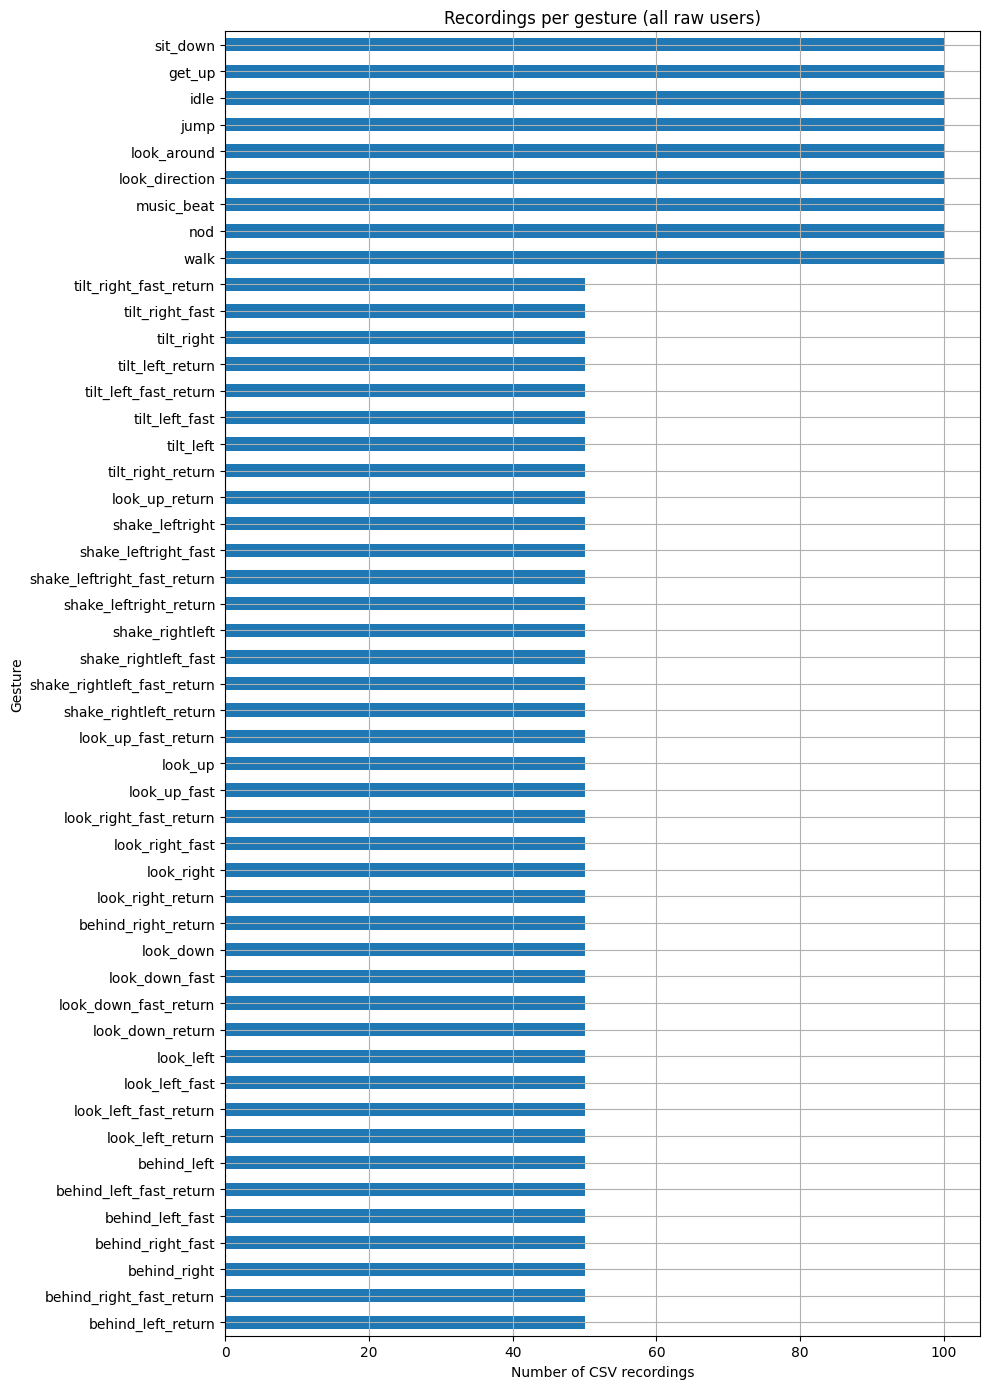

count     49.000000
mean      59.183673
std       19.561520
min       50.000000
25%       50.000000
50%       50.000000
75%       50.000000
max      100.000000
Name: count, dtype: float64

In [26]:
gesture_counts = meta["gesture"].value_counts().sort_values(ascending=True)
ax = gesture_counts.plot(kind="barh", figsize=(10, 14), title="Recordings per gesture (all raw users)")
ax.set_xlabel("Number of CSV recordings")
ax.set_ylabel("Gesture")
plt.tight_layout()
plt.show()

gesture_counts.describe()


In [27]:
per_user_gesture = meta.pivot_table(index="gesture", columns="user", values="file_name", aggfunc="count", fill_value=0)
per_user_gesture.head(12)


user,User1,User2,User3,User4,User5
gesture,,,,,
behind_left,10,10,10,10,10
behind_left_fast,10,10,10,10,10
behind_left_fast_return,10,10,10,10,10
behind_left_return,10,10,10,10,10
behind_right,10,10,10,10,10
behind_right_fast,10,10,10,10,10
behind_right_fast_return,10,10,10,10,10
behind_right_return,10,10,10,10,10
get_up,20,20,20,20,20


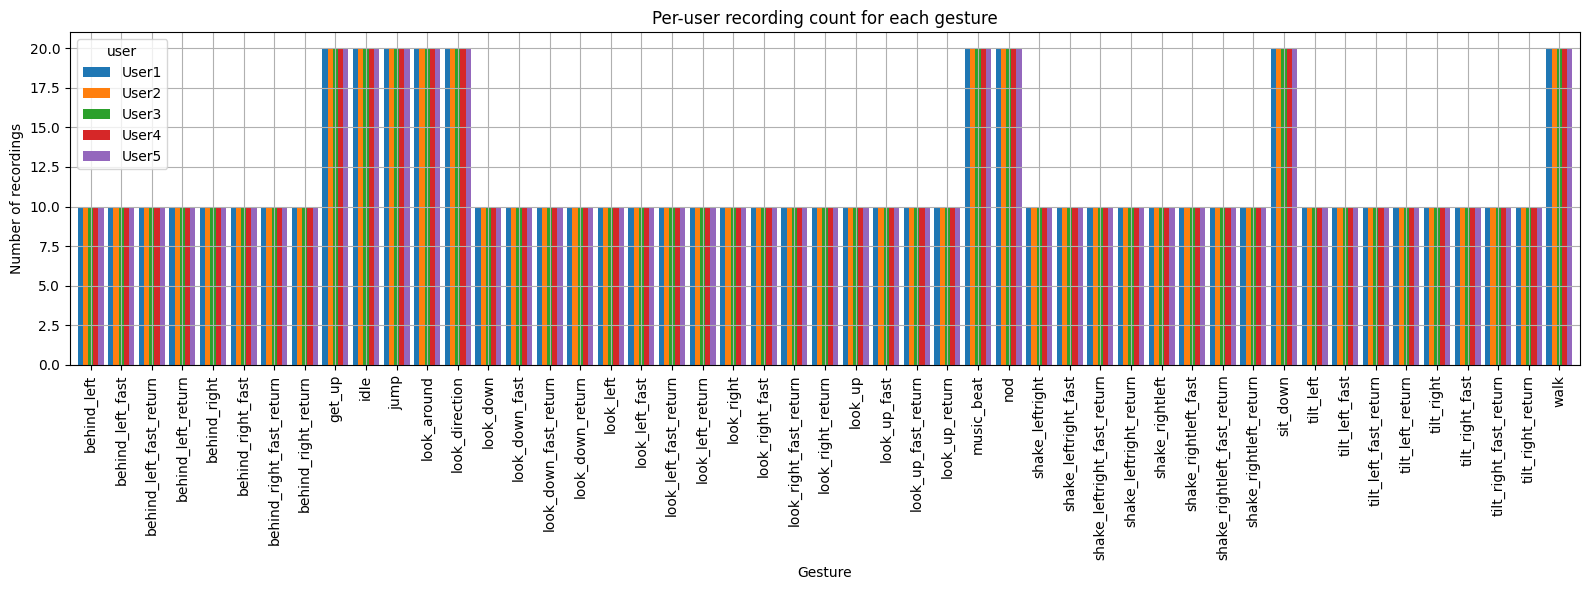

In [28]:
ax = per_user_gesture.sort_index().plot(kind="bar", figsize=(16, 6), width=0.85, title="Per-user recording count for each gesture")
ax.set_xlabel("Gesture")
ax.set_ylabel("Number of recordings")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 4) Recording length analysis

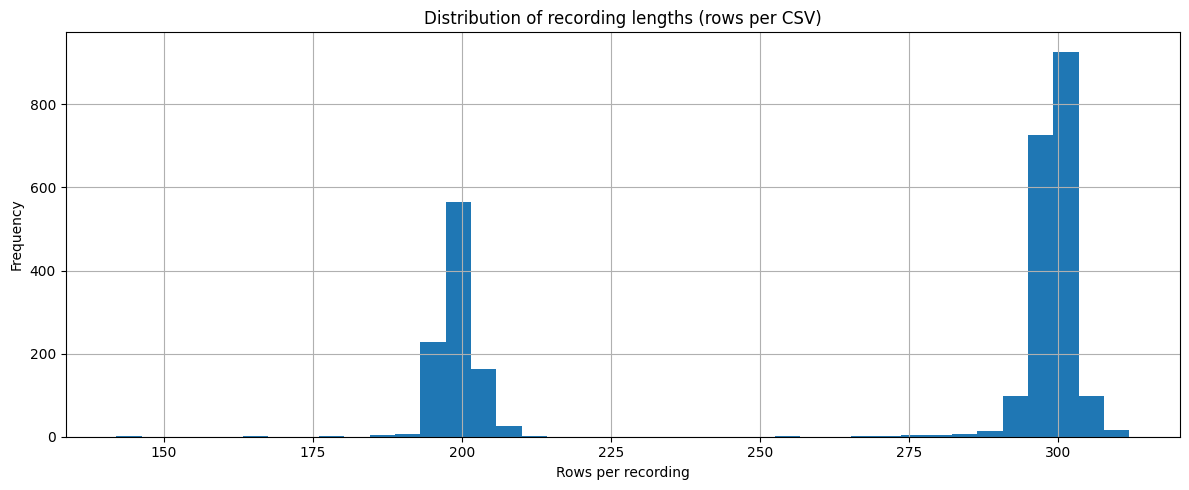

count    2900.000000
mean      264.355172
std        47.699228
min       142.000000
25%       201.000000
50%       297.000000
75%       300.000000
max       312.000000
Name: n_rows, dtype: float64

In [29]:
meta["n_rows"].plot(kind="hist", bins=40, title="Distribution of recording lengths (rows per CSV)")
plt.xlabel("Rows per recording")
plt.tight_layout()
plt.show()

meta["n_rows"].describe()


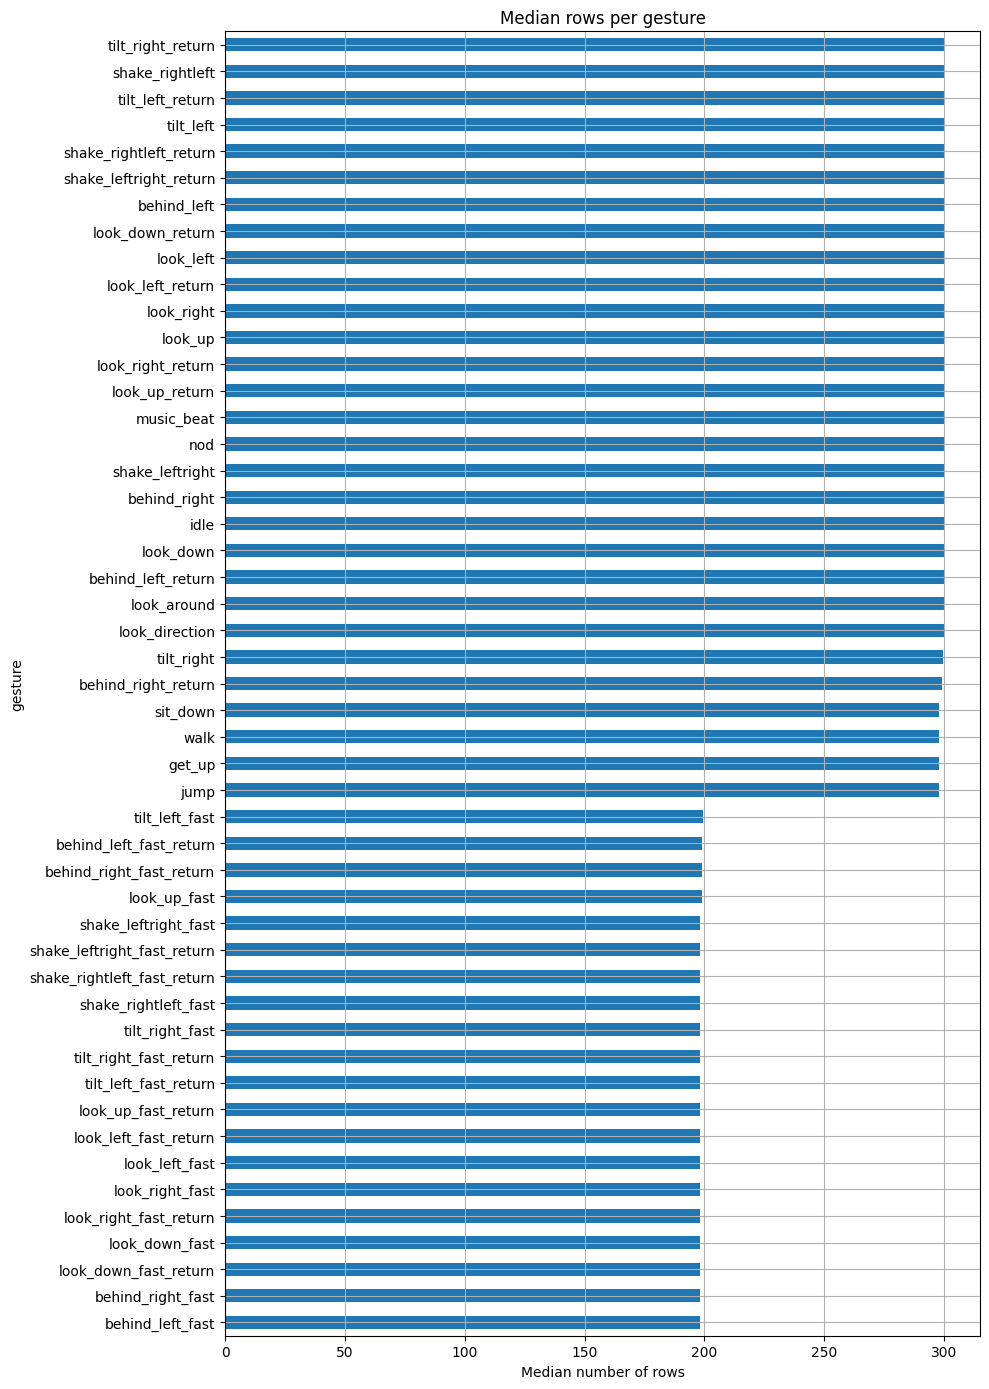

gesture
look_left_return          300.0
look_left                 300.0
look_down_return          300.0
behind_left               300.0
shake_leftright_return    300.0
shake_rightleft_return    300.0
tilt_left                 300.0
tilt_left_return          300.0
shake_rightleft           300.0
tilt_right_return         300.0
Name: n_rows, dtype: float64

In [30]:
median_len_by_gesture = meta.groupby("gesture")["n_rows"].median().sort_values()
ax = median_len_by_gesture.plot(kind="barh", figsize=(10, 14), title="Median rows per gesture")
ax.set_xlabel("Median number of rows")
plt.tight_layout()
plt.show()

median_len_by_gesture.tail(10)


In [31]:
length_stats = meta.groupby("gesture")["n_rows"].agg(["count", "min", "median", "max", "mean", "std"]).sort_values("median")
length_stats.head(15)


,count,min,median,max,mean,std
gesture,,,,,,
behind_left_fast,50,192,198.0,208,199.30,2.749768
behind_right_fast,50,189,198.0,207,199.18,3.820941
look_down_fast_return,50,193,198.0,208,198.12,3.153489
look_down_fast,50,142,198.0,204,195.96,12.071150
look_right_fast_return,50,166,198.0,206,198.24,5.408082
look_right_fast,50,191,198.0,210,199.28,3.362701
look_left_fast,50,193,198.0,205,199.18,2.438551
look_left_fast_return,50,185,198.0,209,198.84,3.587734
look_up_fast_return,50,192,198.0,209,199.34,3.566339


## 5) Timestamp behavior

In [32]:
meta["timestamp_median_step"].describe()


count    2900.0
mean        1.0
std         0.0
min         1.0
25%         1.0
50%         1.0
75%         1.0
max         1.0
Name: timestamp_median_step, dtype: float64

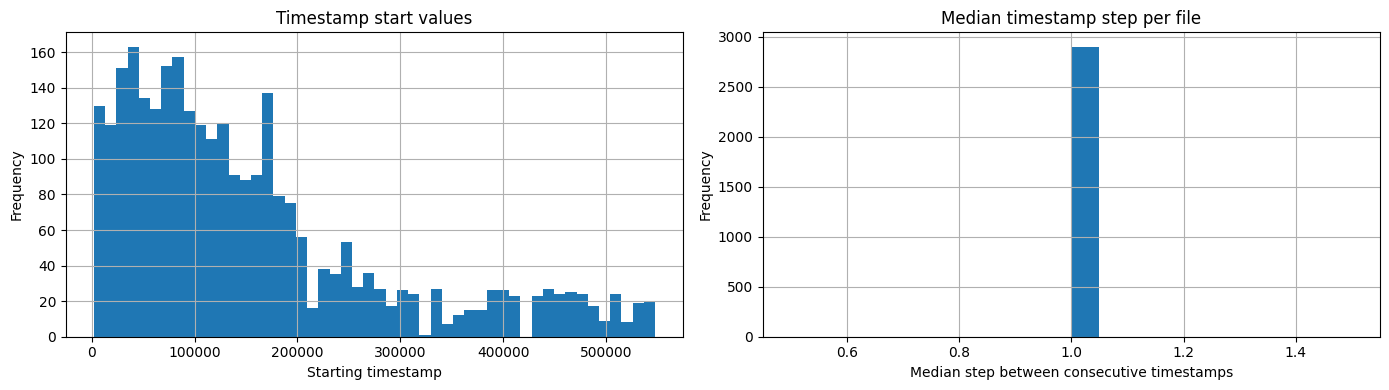

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
meta["timestamp_start"].plot(kind="hist", bins=50, ax=axes[0], title="Timestamp start values")
axes[0].set_xlabel("Starting timestamp")
meta["timestamp_median_step"].dropna().plot(kind="hist", bins=20, ax=axes[1], title="Median timestamp step per file")
axes[1].set_xlabel("Median step between consecutive timestamps")
plt.tight_layout()
plt.show()


In [34]:
meta[["user", "gesture", "file_name", "timestamp_start", "timestamp_end", "timestamp_median_step"]].head(10)


,user,gesture,file_name,timestamp_start,timestamp_end,timestamp_median_step
0,User1,behind_left,behind_left_1.csv,398668.0,398967.0,1.0
1,User1,behind_left,behind_left_10.csv,402276.0,402573.0,1.0
2,User1,behind_left,behind_left_2.csv,399066.0,399368.0,1.0
3,User1,behind_left,behind_left_3.csv,399467.0,399768.0,1.0
4,User1,behind_left,behind_left_4.csv,399873.0,400168.0,1.0
5,User1,behind_left,behind_left_5.csv,400270.0,400570.0,1.0
6,User1,behind_left,behind_left_6.csv,400672.0,400971.0,1.0
7,User1,behind_left,behind_left_7.csv,401074.0,401369.0,1.0
8,User1,behind_left,behind_left_8.csv,401477.0,401774.0,1.0
9,User1,behind_left,behind_left_9.csv,401877.0,402173.0,1.0


## 6) Representative signal plots

In [35]:
def load_recording(row):
    return pd.read_csv(row["path"])

def plot_recording(df, title=""):
    fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    accel_cols = ["x_accel", "y_accel", "z_accel"]
    gyro_cols = ["x_gyro", "y_gyro", "z_gyro"]
    df[accel_cols].plot(ax=axes[0], title=f"{title} — Accelerometer")
    axes[0].set_ylabel("Accel")
    df[gyro_cols].plot(ax=axes[1], title=f"{title} — Gyroscope")
    axes[1].set_ylabel("Gyro")
    axes[1].set_xlabel("Sample index")
    plt.tight_layout()
    plt.show()


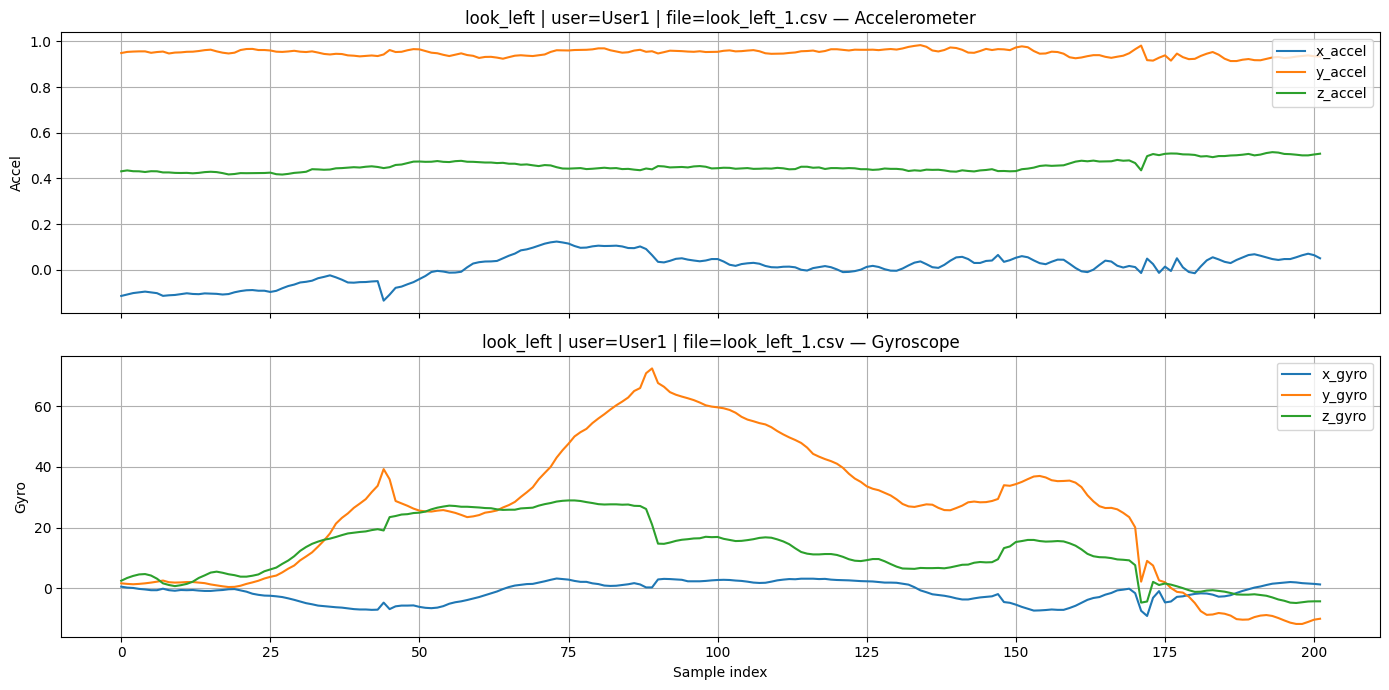

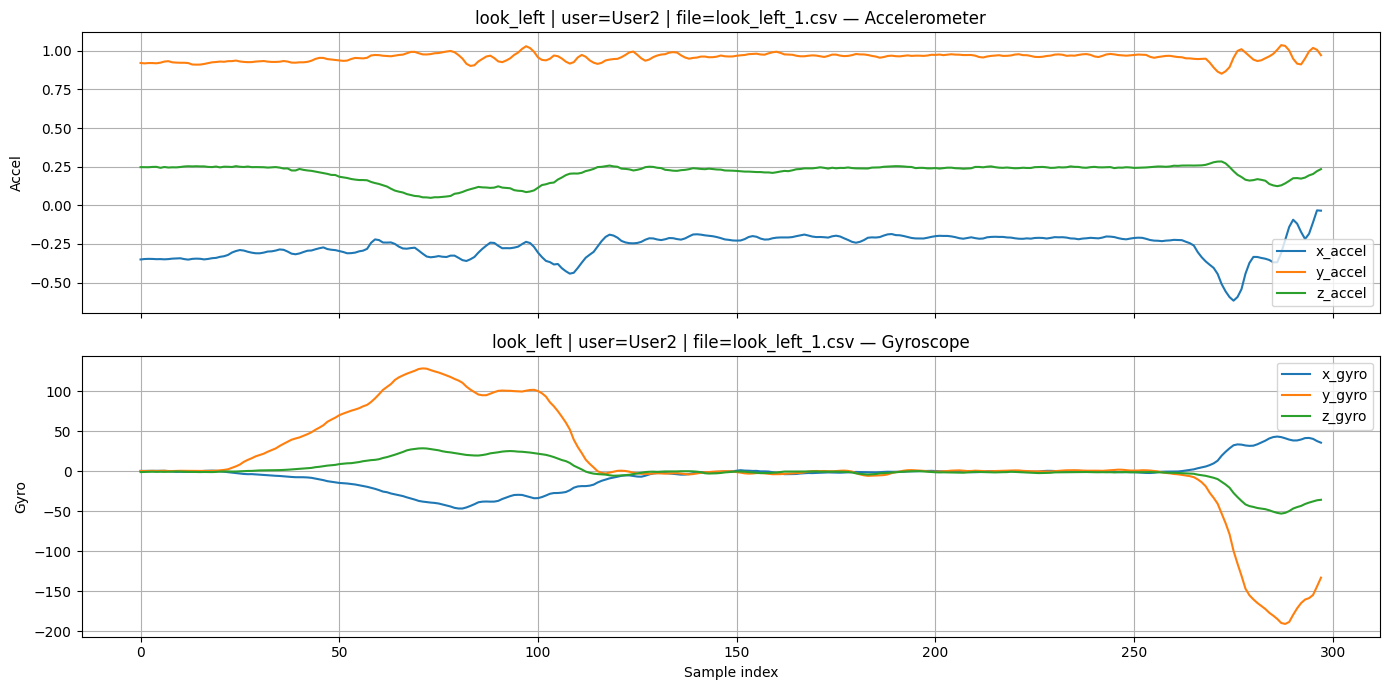

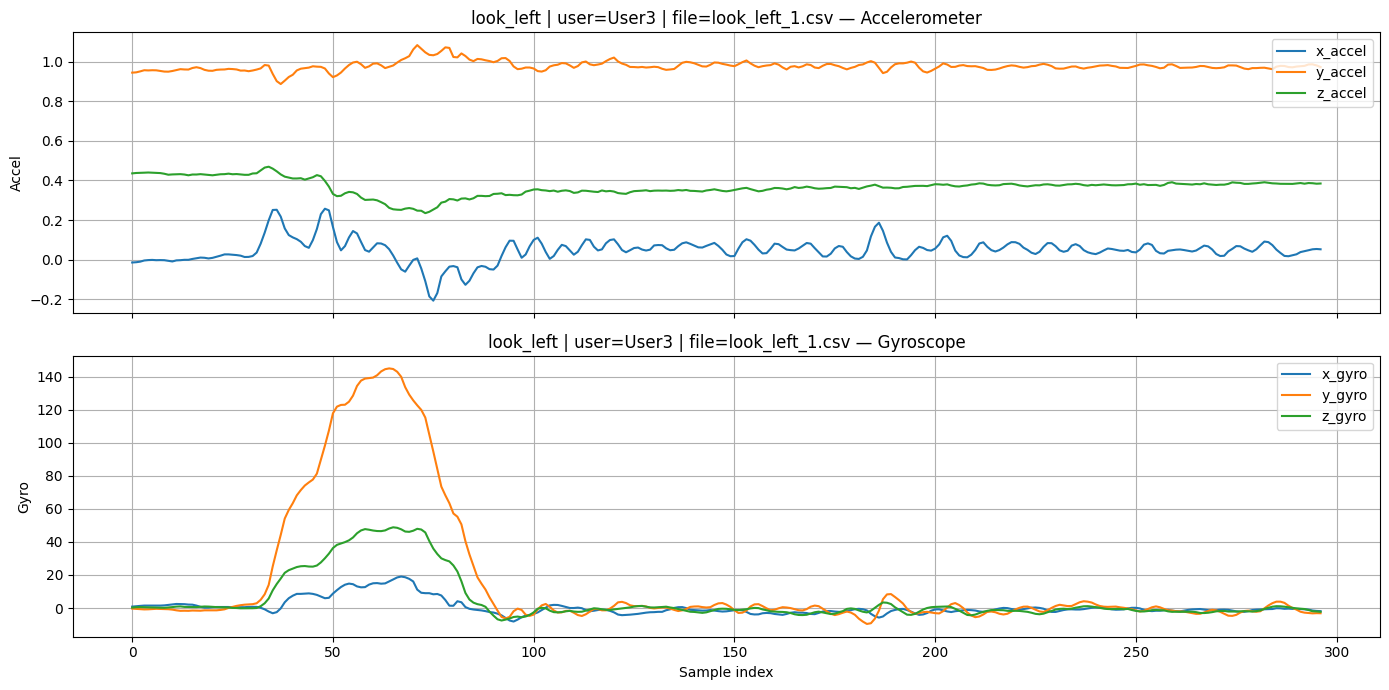

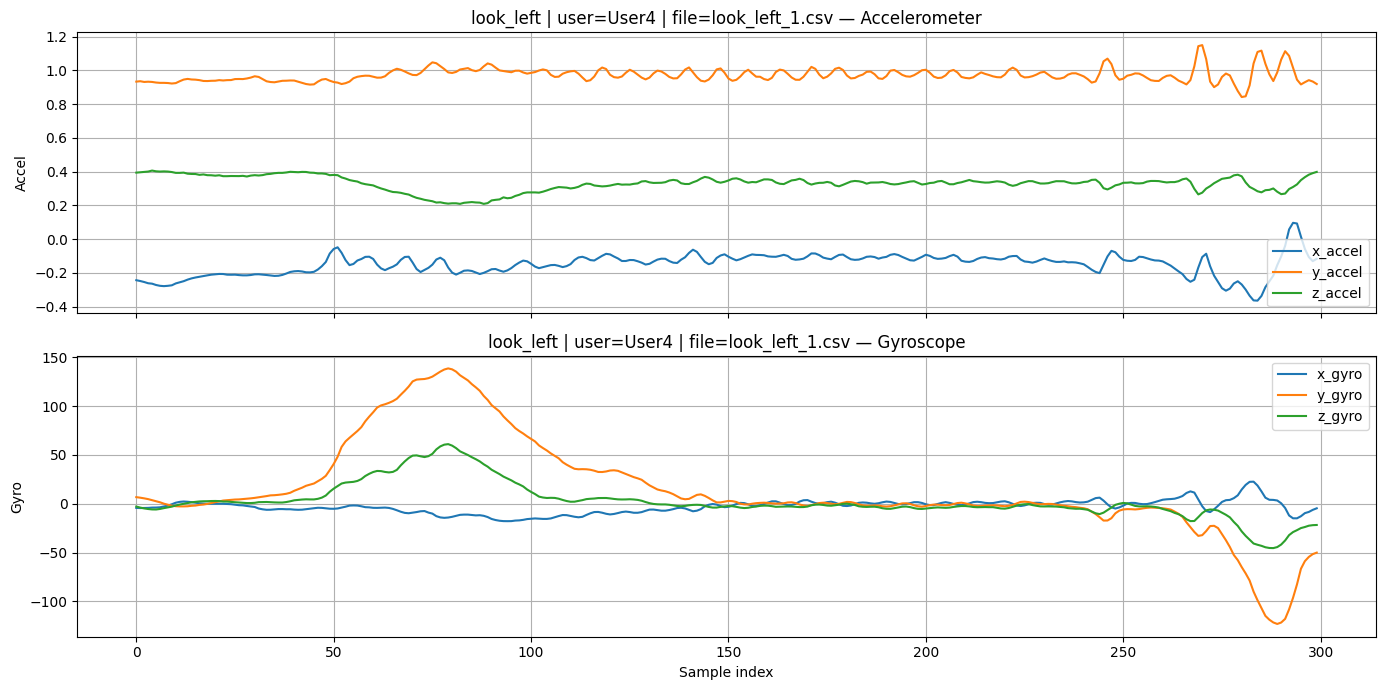

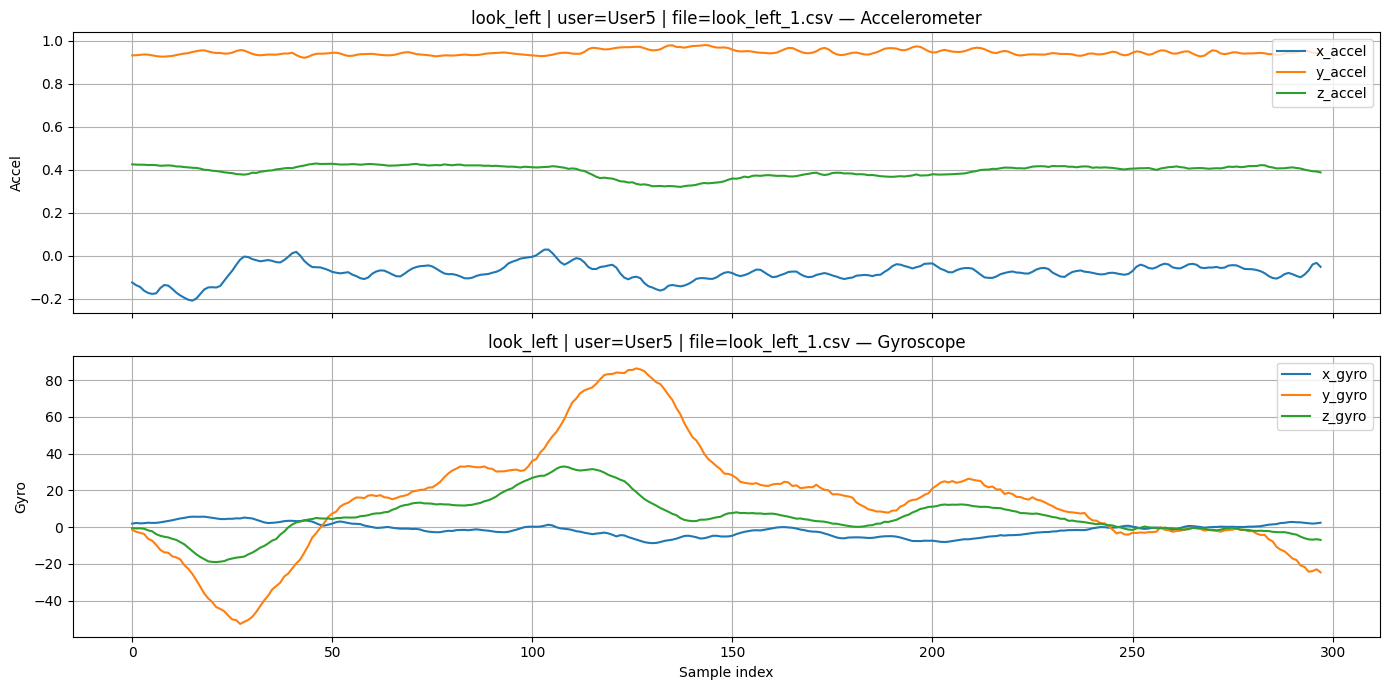

In [36]:
gesture_to_plot = "look_left"
for user in sorted(meta["user"].unique()):
    row = meta[(meta["user"] == user) & (meta["gesture"] == gesture_to_plot)].iloc[0]
    df = load_recording(row)
    plot_recording(df, title=f"{gesture_to_plot} | user={user} | file={row['file_name']}")


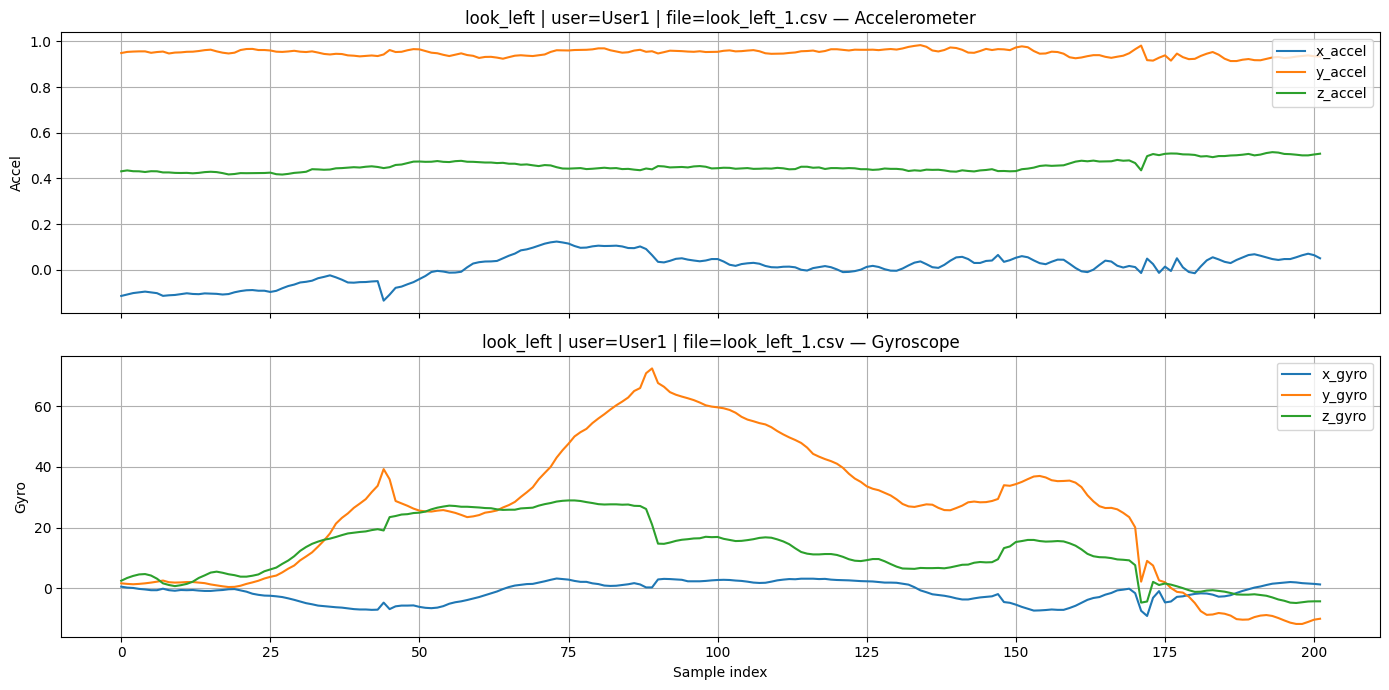

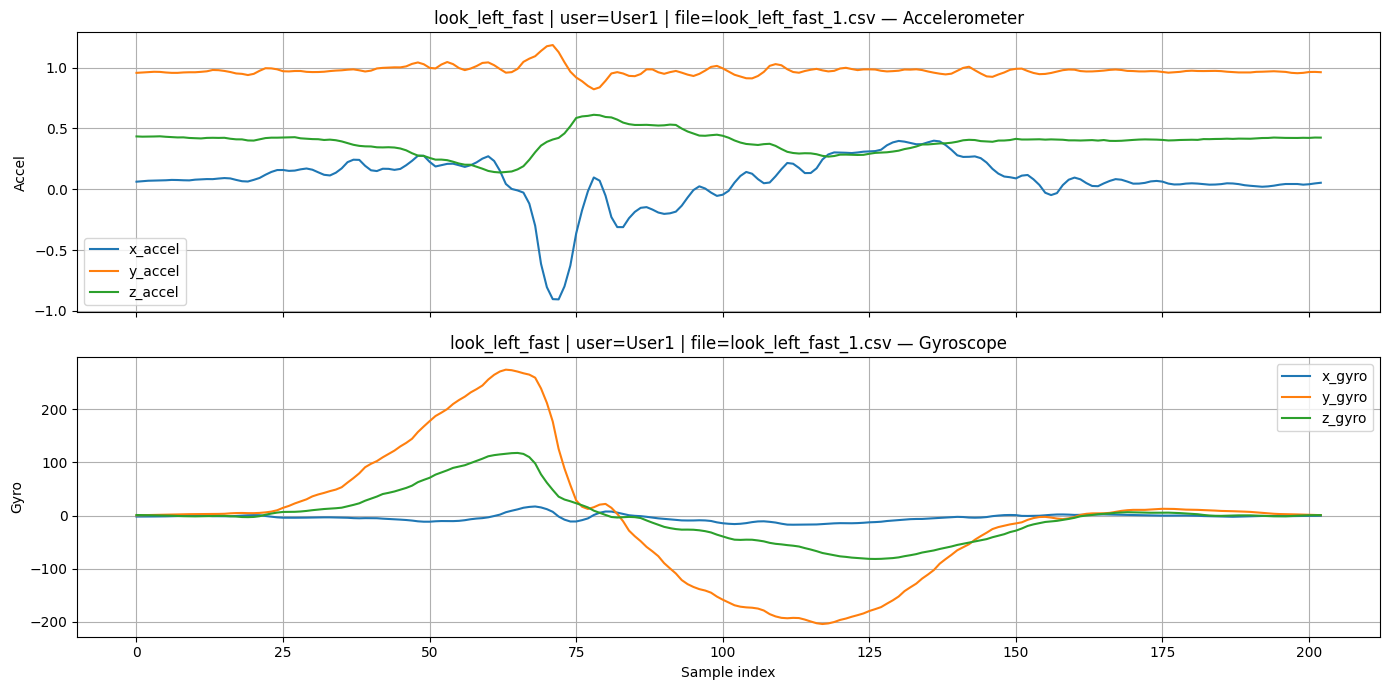

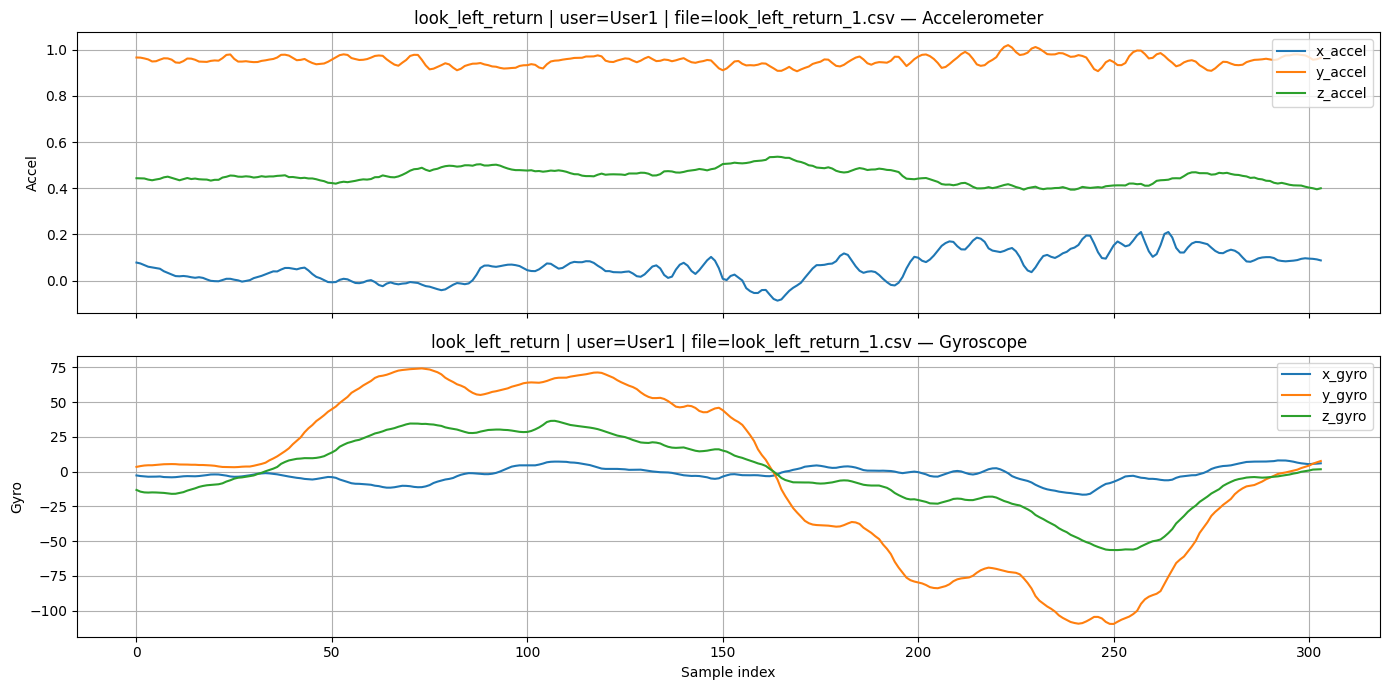

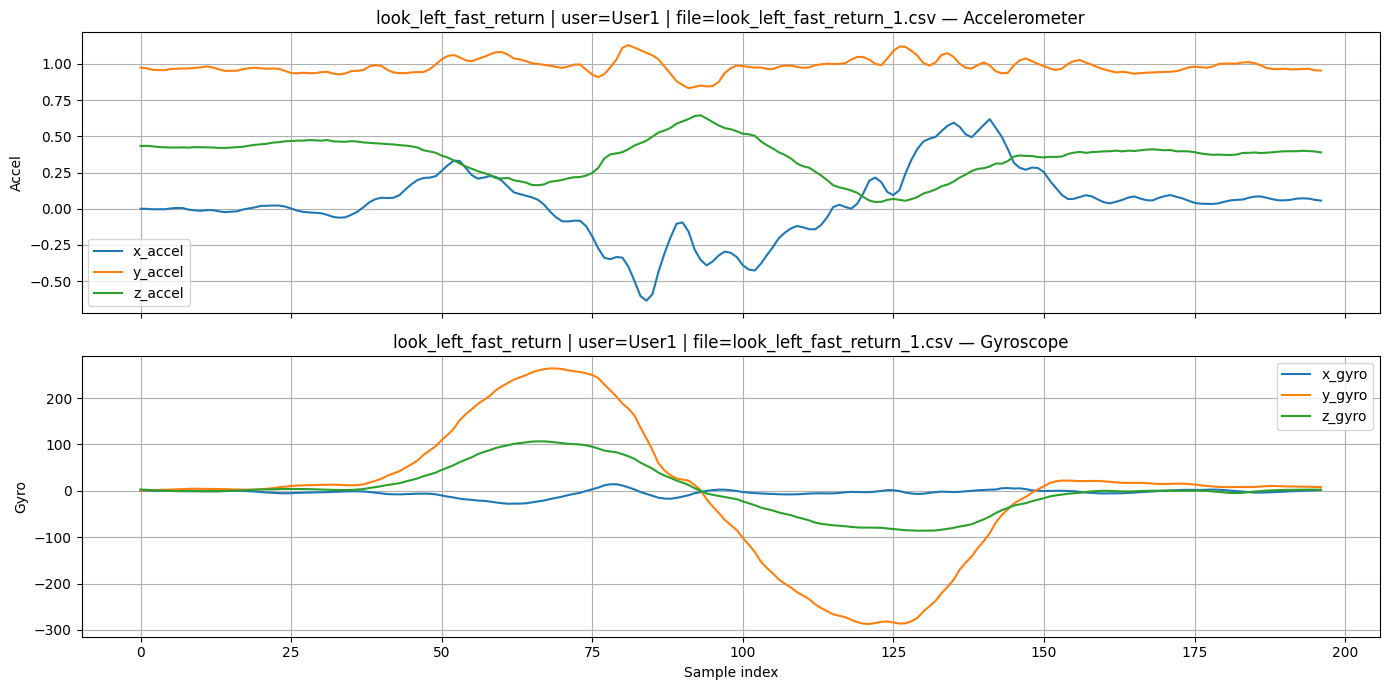

In [41]:
user_to_plot = "User1"
variant_gestures = ["look_left", "look_left_fast", "look_left_return", "look_left_fast_return"]
for g in variant_gestures:
    subset = meta[(meta["user"] == user_to_plot) & (meta["gesture"] == g)]
    if len(subset):
        row = subset.iloc[0]
        df = load_recording(row)
        plot_recording(df, title=f"{g} | user={user_to_plot} | file={row['file_name']}")


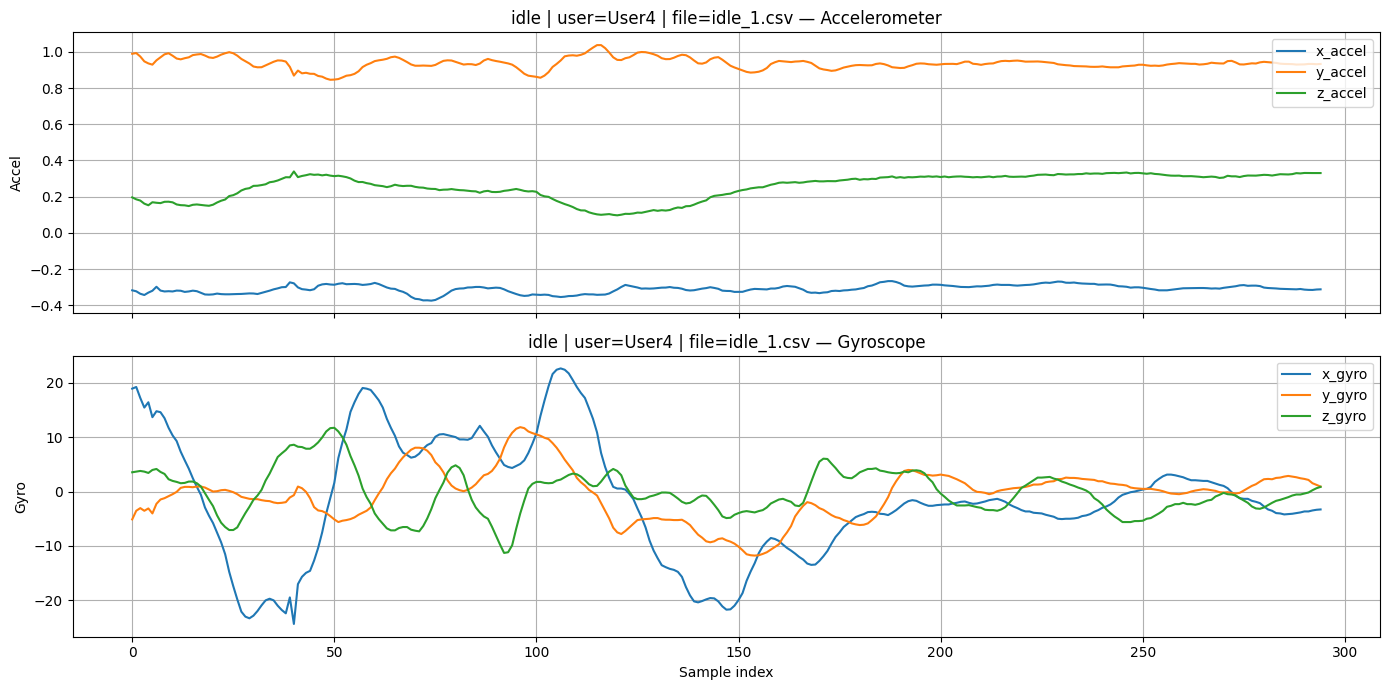

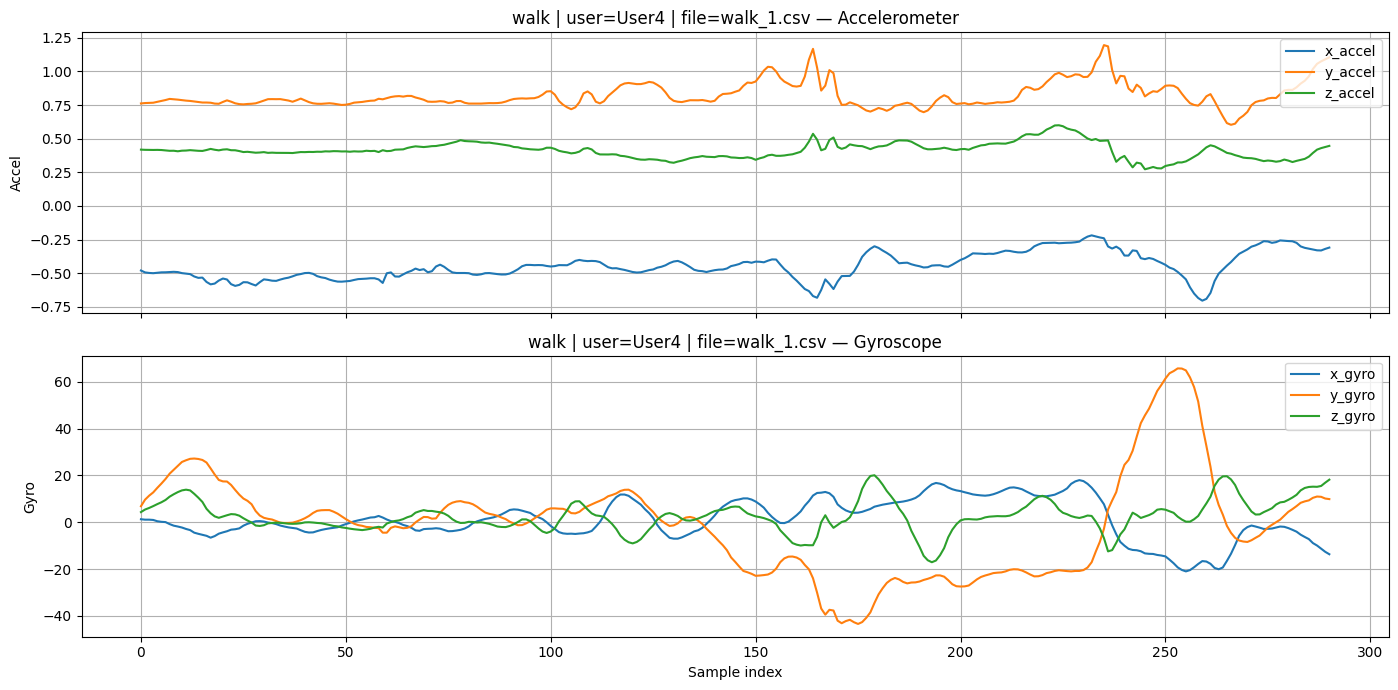

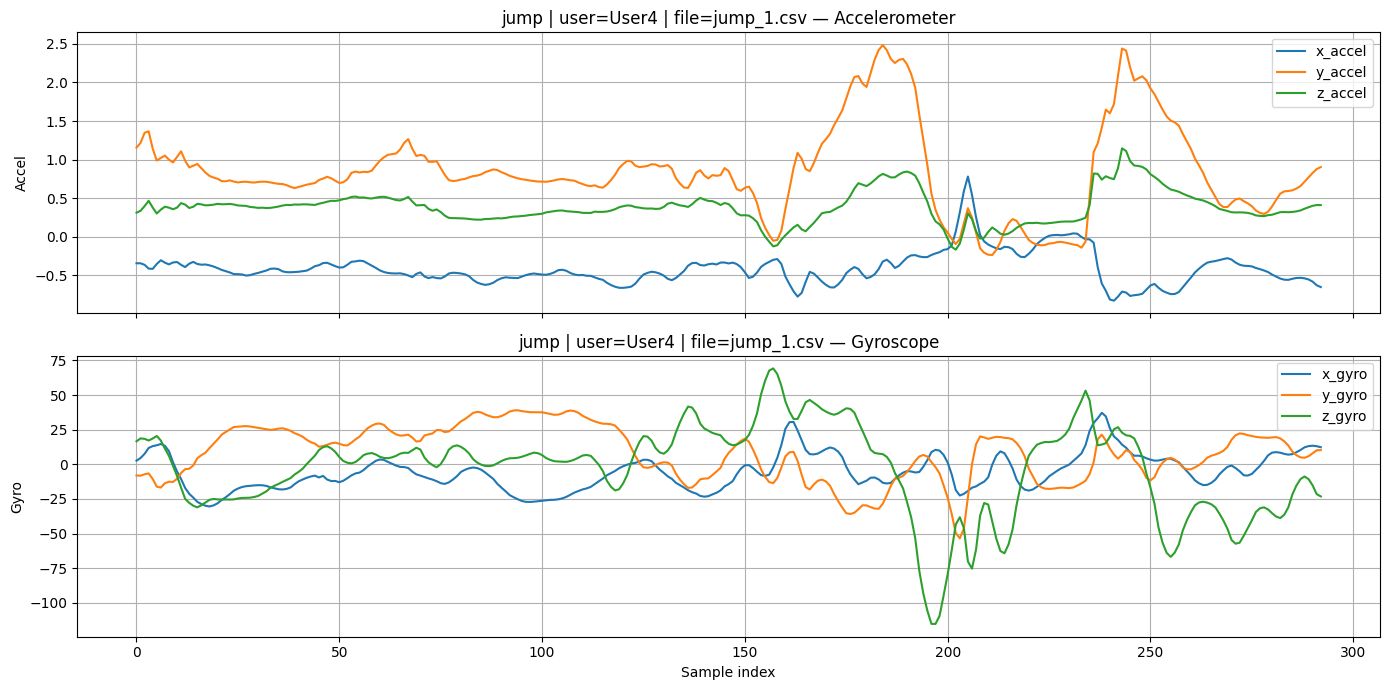

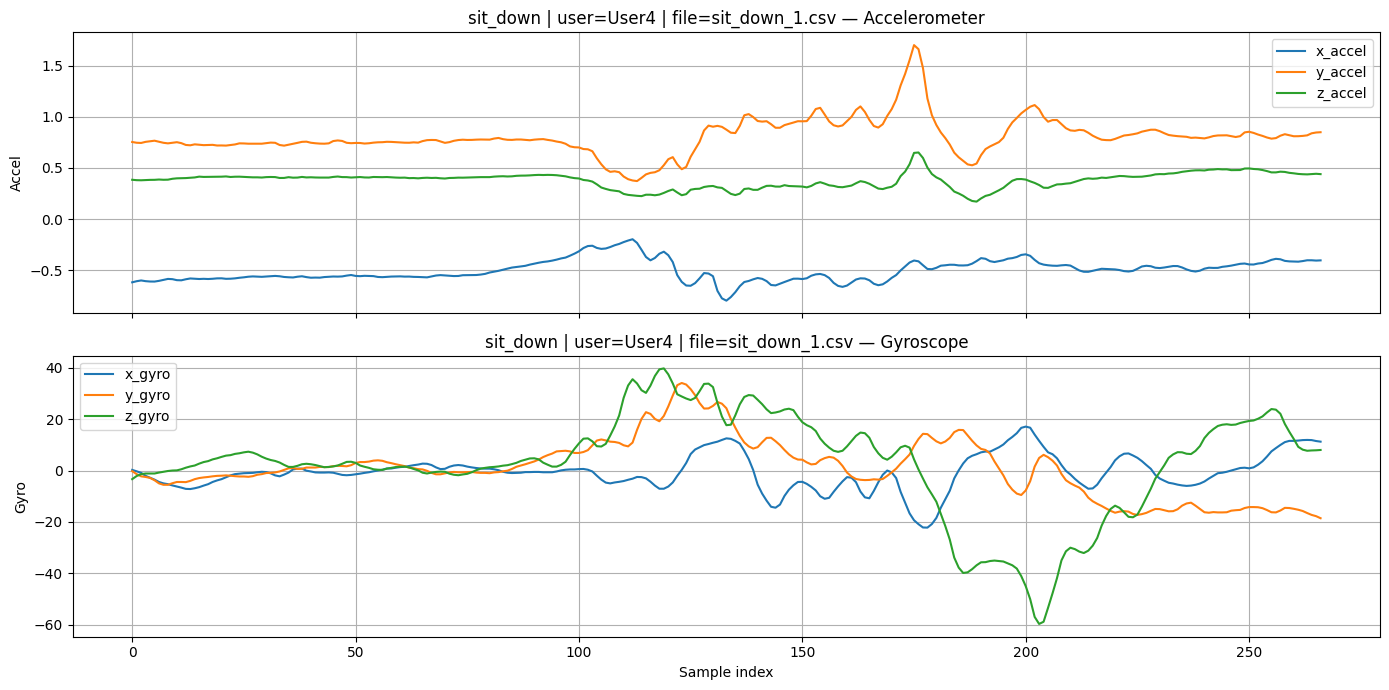

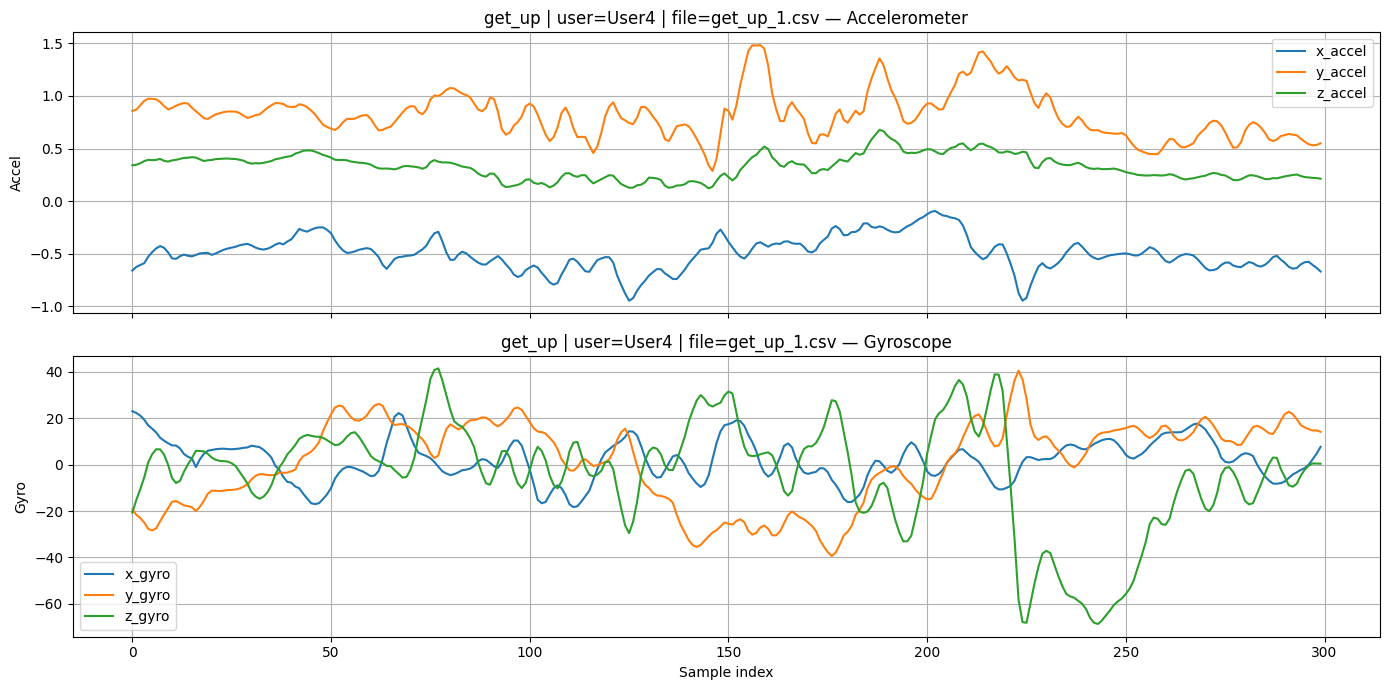

In [42]:
user_to_plot = "User4"
activity_gestures = ["idle", "walk", "jump", "sit_down", "get_up"]
for g in activity_gestures:
    subset = meta[(meta["user"] == user_to_plot) & (meta["gesture"] == g)]
    if len(subset):
        row = subset.iloc[0]
        df = load_recording(row)
        plot_recording(df, title=f"{g} | user={user_to_plot} | file={row['file_name']}")


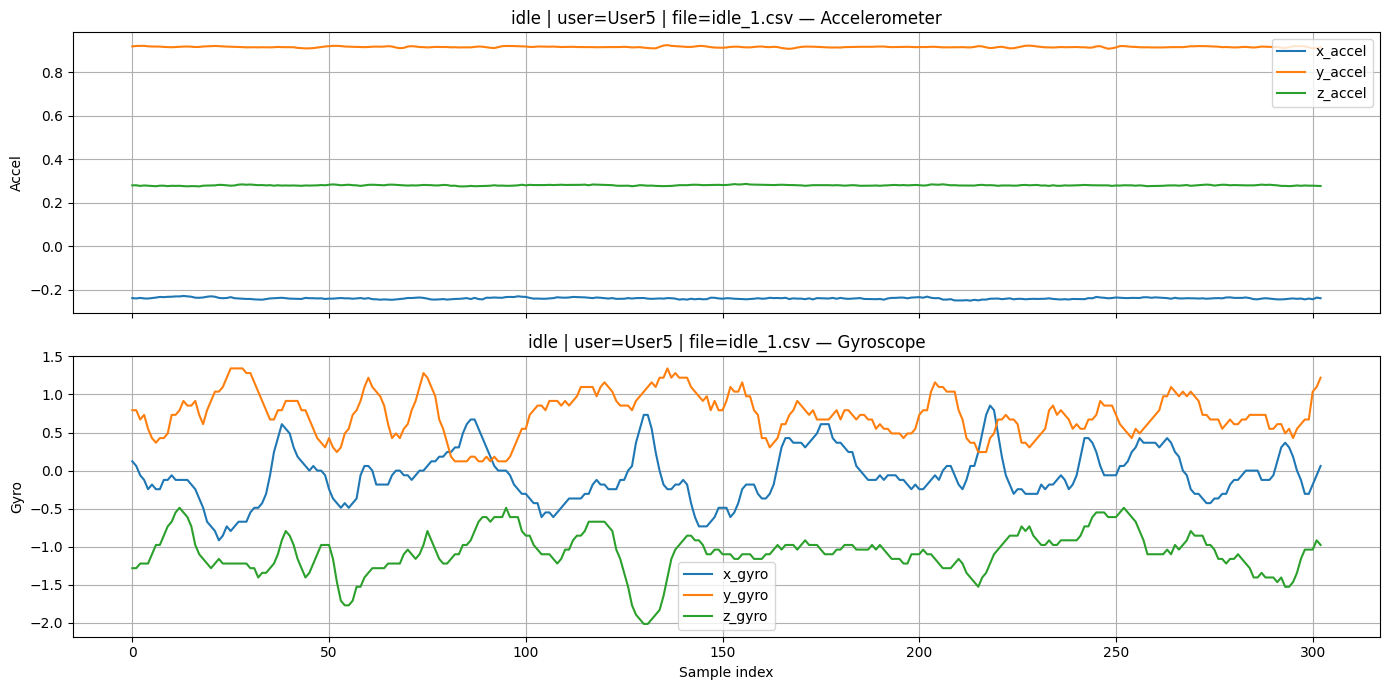

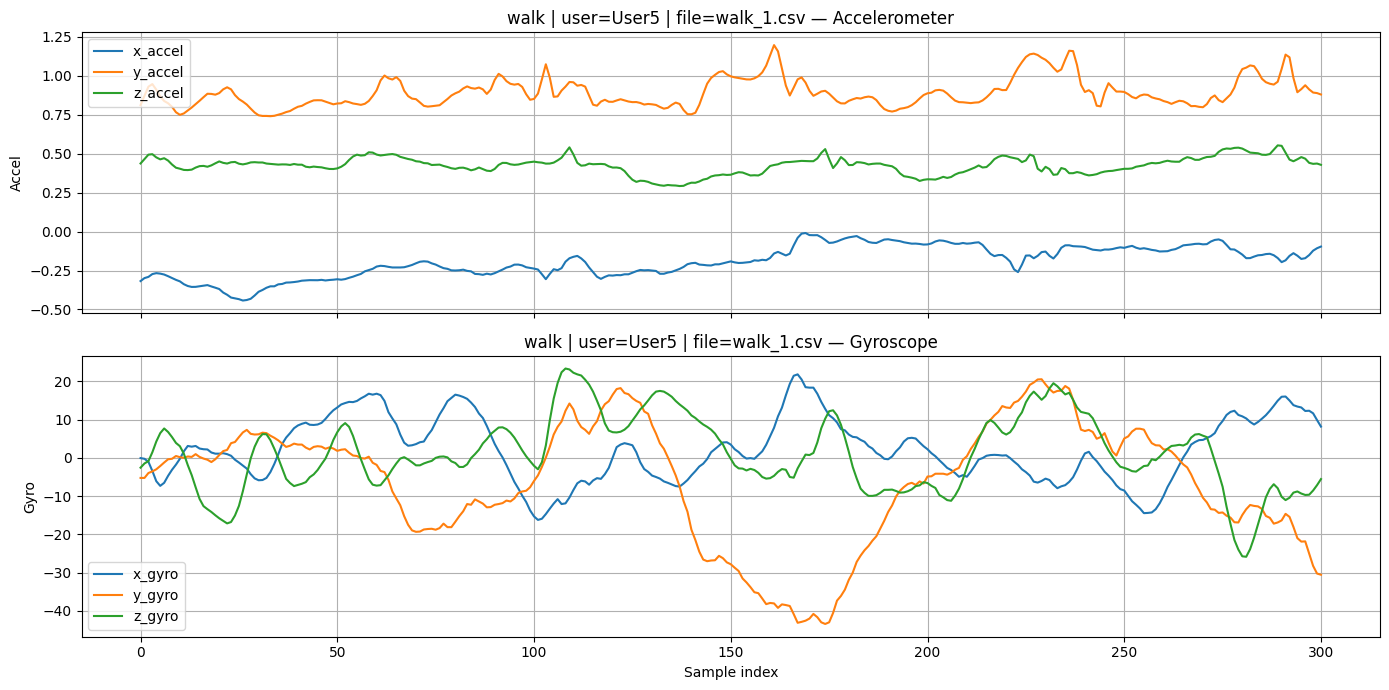

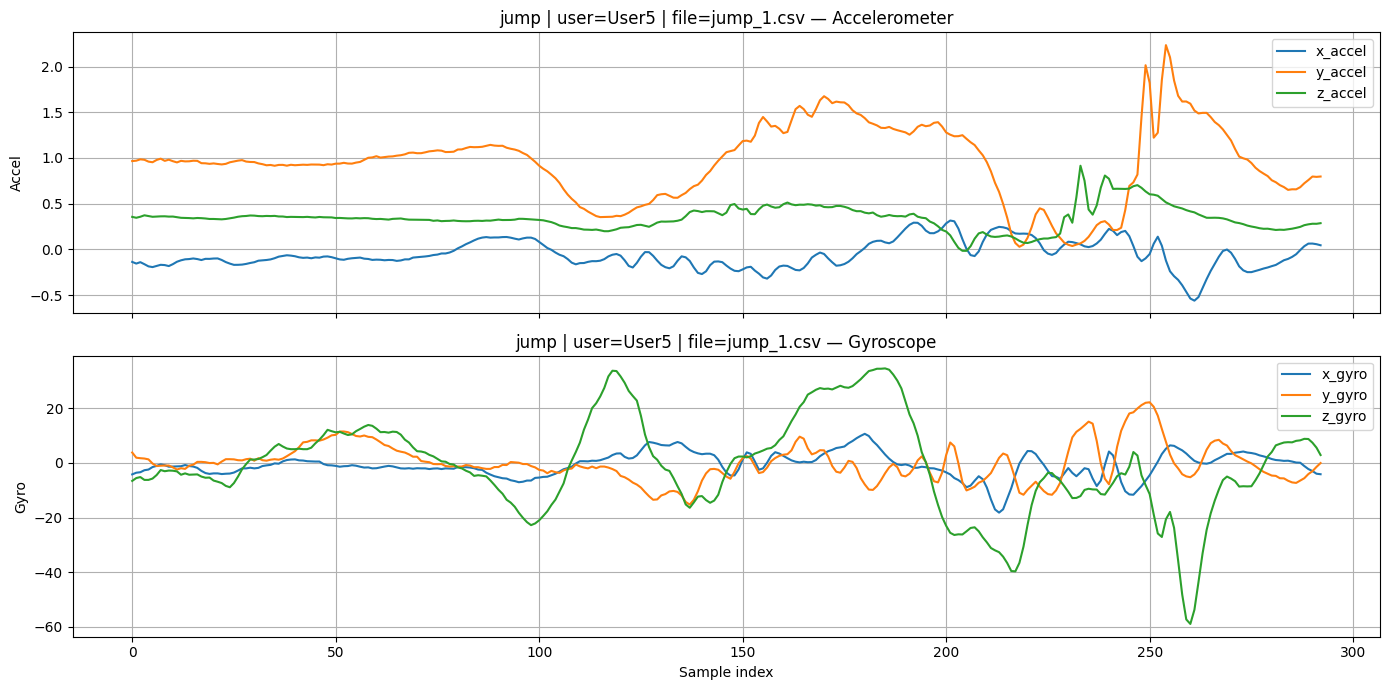

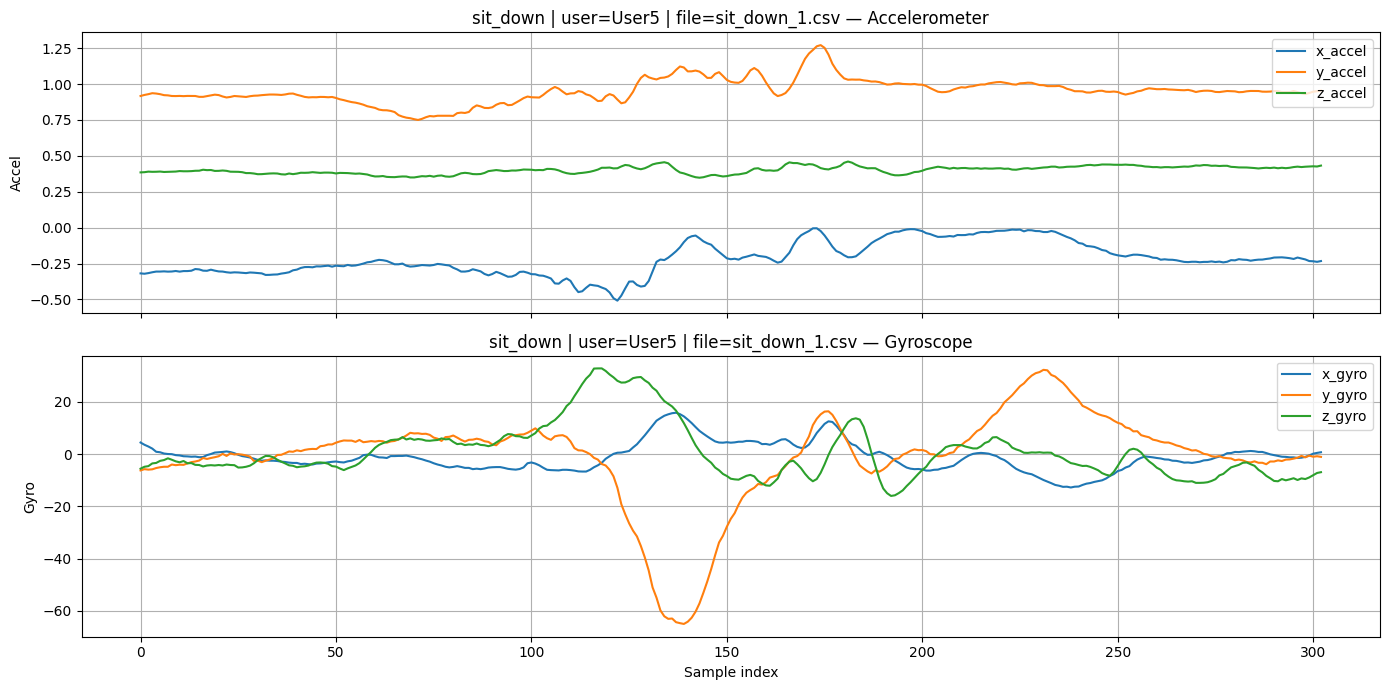

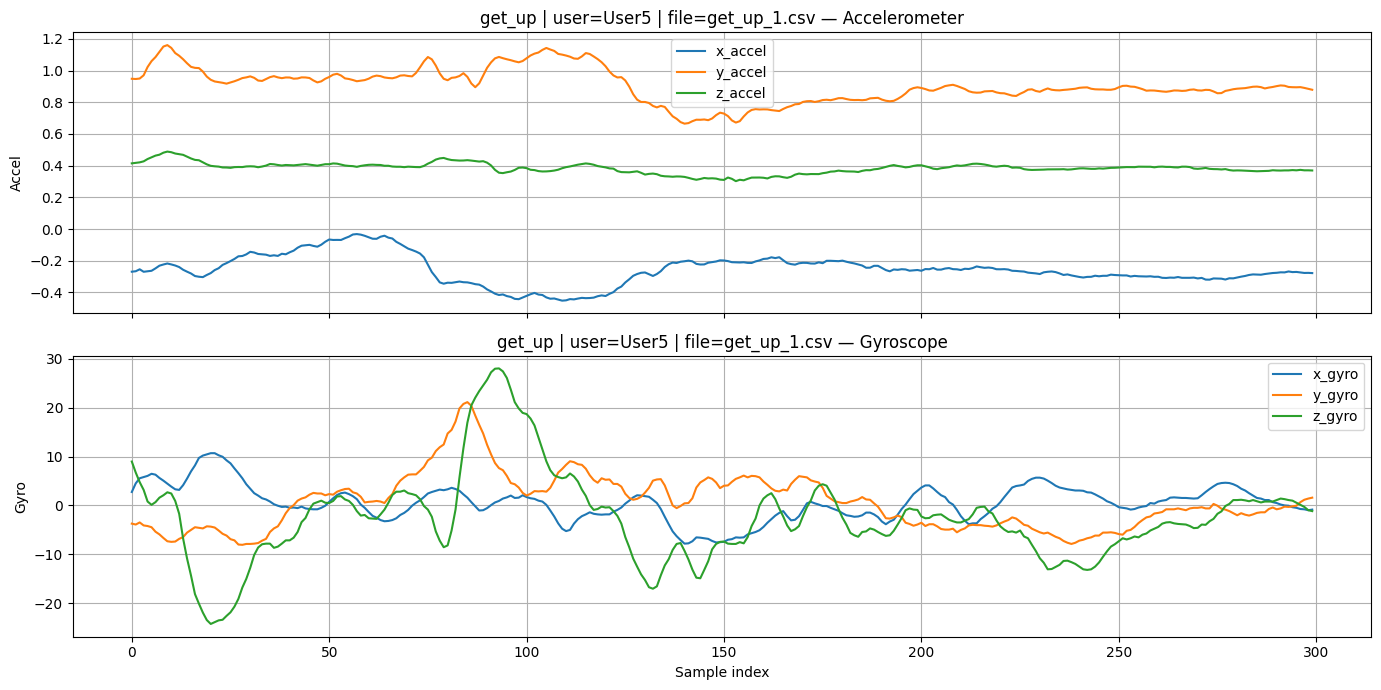

In [43]:
user_to_plot = "User5"
activity_gestures = ["idle", "walk", "jump", "sit_down", "get_up"]
for g in activity_gestures:
    subset = meta[(meta["user"] == user_to_plot) & (meta["gesture"] == g)]
    if len(subset):
        row = subset.iloc[0]
        df = load_recording(row)
        plot_recording(df, title=f"{g} | user={user_to_plot} | file={row['file_name']}")


## 7) Quick takeaways

In [44]:
takeaways = pd.DataFrame({
    "observation": [
        "Total users",
        "Total recordings",
        "Distinct gesture labels",
        "Files with required schema",
        "Empty files",
        "Files containing NaNs",
        "Per-user recording count is balanced",
        "Timestamp monotonicity issues",
    ],
    "value": [
        meta["user"].nunique(),
        len(meta),
        meta["gesture"].nunique(),
        int(meta["has_required_columns"].sum()),
        int(meta["empty_file"].sum()),
        int((meta["na_total"] > 0).sum()),
        meta["user"].value_counts().nunique() == 1,
        int((~meta["timestamp_monotonic_non_decreasing"]).sum()),
    ]
})
takeaways


,observation,value
0,Total users,5
1,Total recordings,2900
2,Distinct gesture labels,49
3,Files with required schema,2900
4,Empty files,0
5,Files containing NaNs,0
6,Per-user recording count is balanced,True
7,Timestamp monotonicity issues,0
